# Lista 4

## Pandas: dane tabluarne

(6pkt + 3pkt)

Na liście znajdują się 2 zadania. Podczas ćwiczeń wykonaj jedno z nich. Po rozwiązaniu zadania pokaż kod prowadzącemu i odpowiedz na **pytanie kontrolne** — tylko wtedy przyznajemy punkty. Dodatkowo prześlij zadanie na platformie skos.

Zadanie dodatkowe oznaczone jest ⭐️. Za wykonanie zadania otrzymasz 3pkt.

## Titanic Dataset

Przeanalizuj zbiór danych [**Titanic Dataset**](https://www.kaggle.com/datasets/yasserh/titanic-dataset?utm_source=chatgpt.com). Znajdź ciekawe informacje i zależności.

> **Uwaga:** Nie musisz wykonywać poniższego polecenia, ale może ono pomóc oszacować nakład pracy potrzebny na zdobycie maksymalnej liczby punktów. Możesz samodzielnie zbadać ten zbiór danych.

### Zadania

Wczytaj bazę danych i wykonaj poniższe polecenia:

1. Wyświetl początek danych (`head()`) oraz opis statystyczny (`describe()`).
2. Znajdź wszystkich pasażerów płci żeńskiej, którzy przeżyli (`Survived == 1`).
3. Oblicz średnią i medianę ceny biletu (`Fare`).
4. Policz, ilu mężczyzn i kobiet znajduje się w danych (`value_counts()` dla kolumny `Sex`).
5. Oblicz procent przeżycia kobiet i mężczyzn w tym zbiorze.
6. Dodaj kolumnę `IsChild` — oznacz pasażerów poniżej 18 roku życia. Następnie zobacz, ilu z nich przeżyło.
7. Sprawdź, ilu pasażerów klasy 1 i klasy 3 przeżyło, używając filtrowania (`Pclass`).
8. Znajdź wszystkich pasażerów, którzy:
    - zapłacili więcej niż średnia cena biletu (`Fare > mean_fare`),
    - byli kobietami,
    - oraz przeżyli.

    Posortuj wynik malejąco po `Fare`.

> **Wskazówka:** Całość można wykonać w ok. 13 linijkach kodu Pandas.


/var/folders/pt/120626514sj_lgs4_d10nxjm0000gn/T/ipykernel_4830/451614017.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = data.groupby('AgeGroup').agg(


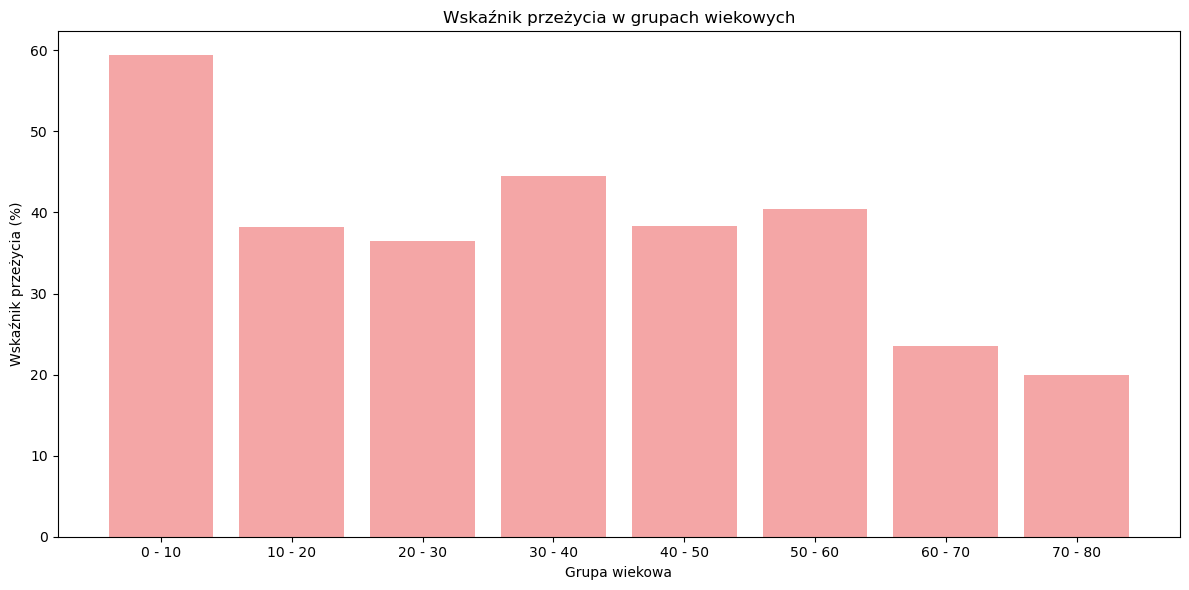

In [15]:
# Praca wspólna z Mateusz Matyskiel oraz Marcin Mularczyk

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


data = pd.read_csv("data/Titanic-Dataset.csv")
age_bins = np.arange(0, data['Age'].max() + 10, 10)
data['AgeGroup'] = pd.cut(data['Age'], bins=age_bins)
age_survival = data.groupby('AgeGroup').agg(
    total_passengers=('Survived', 'count'),
    survived=('Survived', 'sum')
)
age_survival['survival_rate'] = \
    (age_survival['survived'] / age_survival['total_passengers']) * 100
x_positions = [f"{i * 10} - {(i+1) * 10}" for i in range(len(age_survival))]

plt.figure(figsize=(12, 6))
plt.bar(x_positions, age_survival['survival_rate'], alpha=0.7, color='lightcoral')
plt.title('Wskaźnik przeżycia w grupach wiekowych')
plt.xlabel('Grupa wiekowa')
plt.ylabel('Wskaźnik przeżycia (%)')

plt.tight_layout()
plt.show()




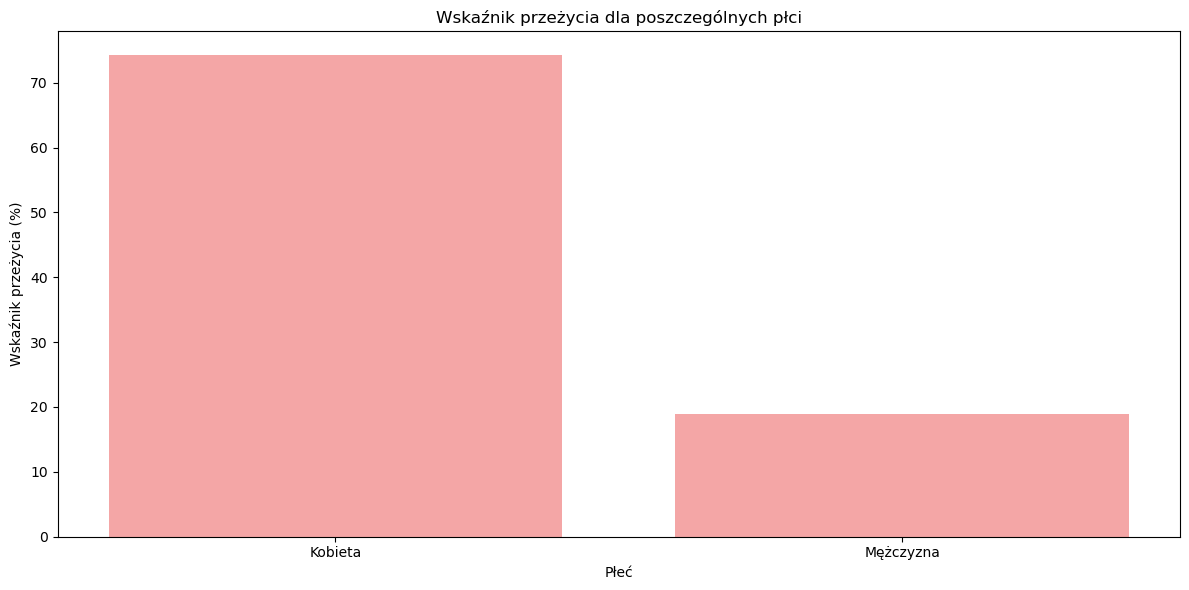

In [18]:
sex_survival = data.groupby("Sex").agg(
    total_passengers = ('Survived', 'count'),
    survived = ('Survived', 'sum')
)
sex_survival['survival_rate'] = \
    (sex_survival['survived'] / sex_survival['total_passengers']) * 100

plt.figure(figsize=(12, 6))
plt.bar(['Kobieta', 'Mężczyzna'], sex_survival['survival_rate'], alpha=0.7, color='lightcoral')
plt.title('Wskaźnik przeżycia dla poszczególnych płci')
plt.xlabel('Płeć')
plt.ylabel('Wskaźnik przeżycia (%)')

plt.tight_layout()
plt.show()

In [20]:
print(data.head(), "\n ---------------------- \n", data.describe())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked      AgeGroup  
0      0         A/5 21171   7.2500   NaN        S  (20.0, 30.0]  
1      0          PC 17599  71.2833   C85        C  (30.0, 40.0]  
2      0  STON/O2. 3101282   7.9250   NaN        S  (20.0, 30.0]  
3      0            113803  53.1000  C123        S  

/var/folders/pt/120626514sj_lgs4_d10nxjm0000gn/T/ipykernel_4830/4009519499.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fare_survival = data.groupby('FareGroup').agg(


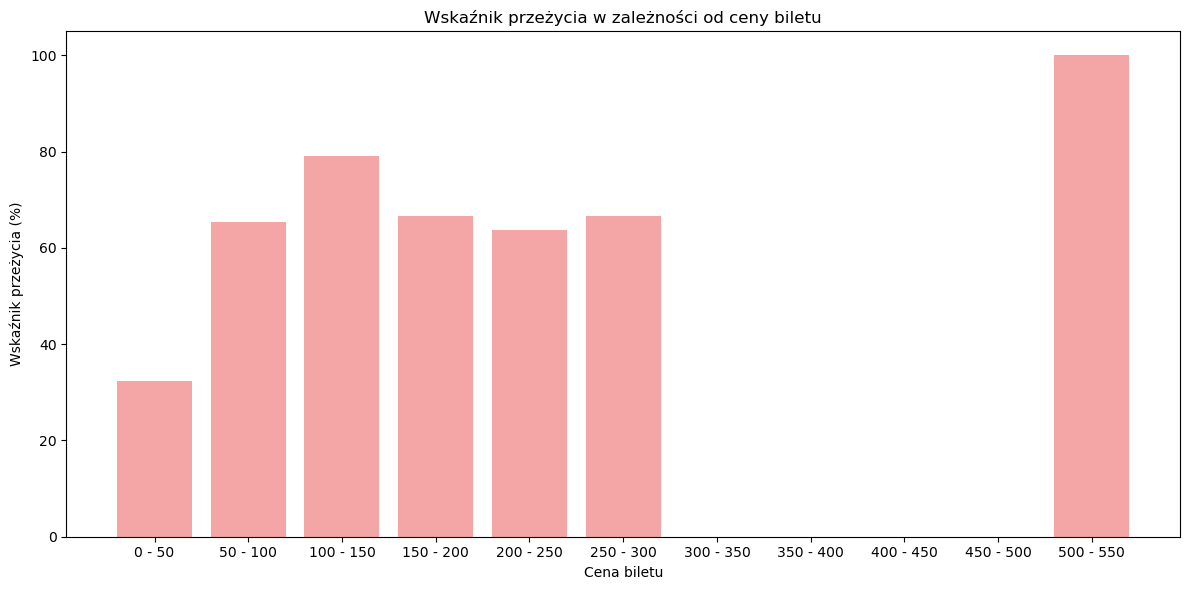

In [24]:
fare_bins = np.arange(0, data['Fare'].max() + 50, 50)

data['FareGroup'] = pd.cut(data['Fare'], bins=fare_bins)
fare_survival = data.groupby('FareGroup').agg(
    total_passengers=('Survived', 'count'),
    survived=('Survived', 'sum')
)
fare_survival['survival_rate'] = \
    (fare_survival['survived'] / fare_survival['total_passengers']) * 100
x_positions = [f"{i * 50} - {(i+1) * 50}" for i in range(len(fare_survival))]

plt.figure(figsize=(12, 6))
plt.bar(x_positions, fare_survival['survival_rate'], alpha=0.7, color='lightcoral')
plt.title('Wskaźnik przeżycia w zależności od ceny biletu')
plt.xlabel('Cena biletu')
plt.ylabel('Wskaźnik przeżycia (%)')

plt.tight_layout()
plt.show()

## Sleep Health and Lifestyle Dataset

Przeanalizuj zbiór danych [**Sleep Health and Lifestyle Dataset**](https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset). Znajdź ciekawe informacje i zależności.

> **Uwaga:** Nie musisz wykonywać poniższego polecenia, ale może ono pomóc oszacować nakład pracy potrzebny na zdobycie maksymalnej liczby punktów. Możesz samodzielnie zbadać ten zbiór danych.

### Zadania

Wczytaj bazę danych i wykonaj poniższe polecenia:

1. Wyświetl początek danych (`head()`) oraz opis statystyczny (`describe()`).
2. Oblicz średni czas snu i średni poziom stresu w całej grupie.
3. Sprawdź, czy dłuższy sen wiąże się z lepszą jakością snu, używając korelacji (`corr()`).  
   > Jeśli korelacja bliska 1 – oznacza silną zależność (więcej snu = lepsza jakość).
4. Znajdź osoby, które:
   - mają `Quality of Sleep >= 8`
   - i `Stress Level <= 5`
5. Stwórz kolumnę `Lifestyle Score`, która będzie prostą miarą jakości stylu życia:  
   Lifestyle Score = (Quality of Sleep) + (Physical Activity Level / 10) - (Stress Level / 2)
6. Sprawdź, czy osoby z kategorią BMI „Overweight” mają niższą jakość snu niż osoby z „Normal”.
7. Sprawdź, czy osoby z wysokim poziomem stresu (`Stress Level > 7`) śpią krócej niż 6 godzin.
8. Stwórz kolumny z ciśnienia krwi:

   ```python
   df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
   ```

   Następnie znajdź wszystkich, którzy:

   * mają `Systolic > 125`,
   * `BMI Category == "Overweight"`,
   * `Sleep Duration < 6.5`,

   i posortuj ich malejąco po `Stress Level`.

> **Wskazówka:** Całość można wykonać w ok. 12 linijkach kodu Pandas.


# ⭐️ Most Streamed Spotify Songs 2023

Odpowiedz na poniższe pytania dotyczące zbioru danych.  
Możesz wymienić dowolnych 7 zadań na własne — pamiętaj jednak, by nie były zbyt proste!  

In [2]:
import pandas as pd

df = pd.read_csv('./data/spotify-2023.csv', encoding='latin1')

df.columns = df.columns.str.strip()

numeric_cols = [
    'artist_count',
    'released_year', 'released_month', 'released_day',
    'in_spotify_playlists', 'in_spotify_charts', 'streams',
    'in_apple_playlists', 'in_apple_charts',
    'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts',
    'bpm',
    'danceability_%', 'valence_%', 'energy_%', 'acousticness_%',
    'instrumentalness_%', 'liveness_%', 'speechiness_%'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

int_cols = [
    'artist_count', 'released_year', 'released_month', 'released_day',
    'in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists',
    'in_apple_charts', 'in_deezer_playlists', 'in_deezer_charts',
    'in_shazam_charts', 'bpm'
]

for col in int_cols:
    if df[col].notna().all():
        df[col] = df[col].astype(int)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   track_name            953 non-null    object 
 1   artist(s)_name        953 non-null    object 
 2   artist_count          953 non-null    int64  
 3   released_year         953 non-null    int64  
 4   released_month        953 non-null    int64  
 5   released_day          953 non-null    int64  
 6   in_spotify_playlists  953 non-null    int64  
 7   in_spotify_charts     953 non-null    int64  
 8   streams               952 non-null    float64
 9   in_apple_playlists    953 non-null    int64  
 10  in_apple_charts       953 non-null    int64  
 11  in_deezer_playlists   874 non-null    float64
 12  in_deezer_charts      953 non-null    int64  
 13  in_shazam_charts      896 non-null    float64
 14  bpm                   953 non-null    int64  
 15  key                   8


## Zadanie 1.

**Które utwory są najczęściej dodawane do playlist (suma ze wszystkich platform)?**

**Rozwiązanie:**

In [13]:
import numpy as np

df['all_playlists'] = df['in_spotify_playlists'] + df['in_apple_playlists'] + df['in_deezer_playlists']
song_id = np.argmax(df['all_playlists'])

print(df['track_name'][song_id] + " - " + df['artist(s)_name'][song_id])

Lost - Frank Ocean


## Zadanie 2.

**Czy bardziej taneczne utwory (`danceability_%`) mają wyższą energię (`energy_%`)?** Sprawdź współczynnik korelacji.

**Rozwiązanie:**

In [16]:
correlation = df[['danceability_%', 'energy_%']].corr().iloc[0, 1]
print(f"Współczynnik korelacji między danceability a energy: {correlation:.3f}")

Współczynnik korelacji między danceability a energy: 0.198


## Zadanie 3.

**Które utwory są "taneczne i smutne"?** Czyli `danceability_% > 75` i `valence_% < 50`. Użyj `query()`.

**Rozwiązanie:**

In [19]:
taneczne_smutne = df.query('`danceability_%` > 75 and `valence_%` < 50')
print(taneczne_smutne[['track_name', 'artist(s)_name']])

             track_name               artist(s)_name
8              fukumean                        Gunna
58                  S91                      Karol G
64              Hey Mor                  Ozuna, Feid
87      Me Porto Bonito  Chencho Corleone, Bad Bunny
88               Makeba                         Jain
..                  ...                          ...
931  Major Distribution             Drake, 21 Savage
933      Vigilante Shit                 Taylor Swift
935               On BS             Drake, 21 Savage
939         Spin Bout U             Drake, 21 Savage
945     BackOutsideBoyz                        Drake

[83 rows x 2 columns]


## Zadanie 4.

**Jakie jest średnie tempo (`bpm`) wszystkich utworów wydanych po 2020 roku?**

In [21]:
sredni_bpm = df[df['released_year'] > 2020]['bpm'].mean()
print(sredni_bpm)

123.17672413793103


## Zadanie 5.

**Znajdź najżywszy (`liveness_%`) i najbardziej instrumentalny (`instrumentalness_%`) utwór.** Skorzystaj z `idxmax()`.

**Rozwiązanie:**

In [26]:
liveness_song_id = df['liveness_%'].idxmax()
instrumentalness_song_id = df['instrumentalness_%'].idxmax()
print(f"Piosenka najbardziej żywa: {df['track_name'][liveness_song_id]} - {df['artist(s)_name'][liveness_song_id]}")
print(f"Piosenka najbardziej instrumentalna: {df['track_name'][instrumentalness_song_id]} - {df['artist(s)_name'][instrumentalness_song_id]}")

Piosenka najbardziej żywa: Vai Lï¿½ï¿½ Em Casa  - Marï¿½ï¿½lia Mendonï¿½ï¿½a, George Henrique &
Piosenka najbardziej instrumentalna: Alien Blues - Vundabar


## Zadanie 6.

**Oblicz średnią energię dla utworów z BPM pomiędzy 90 a 130.** Użyj `between()` i `.mean()`.

**Rozwiązanie:**

In [28]:
# --- Korelacja między ilością bpm, a energy
correlation = df[['bpm', 'energy_%']].corr().iloc[0, 1]
print(f"Współczynnik korelacji między bpm a energy: {correlation:.3f}")
# --- Korelacja między żywością, a energy
correlation = df[['liveness_%', 'energy_%']].corr().iloc[0, 1]
print(f"Współczynnik korelacji między żywością a energy: {correlation:.3f}")

Współczynnik korelacji między bpm a energy: 0.026
Współczynnik korelacji między żywością a energy: 0.117


## Zadanie 7.

**Sprawdź, czy utwory z tonacją Major mają wyższy średni `valence_%` (czyli bardziej „pozytywne emocje”) niż Minor.**

**Rozwiązanie:**

In [30]:
major_valence = df[df['mode'] == 'Major']['valence_%'].mean()
minor_valence = df[df['mode'] == 'Minor']['valence_%'].mean()

print(f"Średni valence dla Major: {major_valence:.2f}")
print(f"Średni valence dla Minor: {minor_valence:.2f}")

Średni valence dla Major: 50.14
Średni valence dla Minor: 53.20


## Zadanie 8.

**Który utwór ma najwyższy stosunek energii do akustyczności?** Oblicz nową kolumnę `energy_to_acoustic` i znajdź maksimum.

**Rozwiązanie:**

In [31]:
df['energy_to_acoustic'] = df['energy_%'] / df['acousticness_%']
track_id = df['energy_to_acoustic'].idxmax()

print(f"Piosenka z najwiekszym energy-acoustic ratio: {df['track_name'][track_id]} - {df['artist(s)_name'][track_id]}")


Piosenka z najwiekszym energy-acoustic ratio: Like Crazy - Jimin


## Zadanie 9.

**Które utwory mają ekstremalne (nietypowe) tempo — poniżej 70 lub powyżej 160 BPM — ale mimo to mają wysoką taneczność (`danceability_% > 70`)?**

**Rozwiązanie:**

In [35]:
nietypowe_tempo_taneczne = df.query("`danceability_%` > 70 and (`bpm` < 70 or `bpm` > 160)")
print(nietypowe_tempo_taneczne[['track_name', 'artist(s)_name']])

                              track_name  \
9                        La Bebe - Remix   
34                                   TQG   
78                            Yandel 150   
91             What It Is (Solo Version)   
227                               Normal   
261                        X SI VOLVEMOS   
306                              La Bebe   
356                                WANDA   
368                          LA CANCIï¿½   
456                        Love Language   
547                               Volvï¿   
594                               Sobrio   
607                                 2055   
632                             AM Remix   
674                           Contection   
708                               Jordan   
794                           Mr. Morale   
837  La Llevo Al Cielo (Ft. ï¿½ï¿½engo F   
846                         Keep Driving   
885         Si Te La Encuentras Por Ahï¿   
928                    California Breeze   

                               

## Zadanie 10.

**Policz, ile utworów przekracza 100 mln odtworzeń (`streams > 100_000_000`). Jaki procent wszystkich to stanowi?**

**Rozwiązanie:**

In [41]:
over100mil = df[df['streams'] > 100_000_000]
print(f"Procent piosenek powyżej 100mln odtworzeń: {len(over100mil) / len(df) * 100:.2f}%")

Procent piosenek powyżej 100mln odtworzeń: 83.95%


## Zadanie 11.

**Znajdź utwory, które mają wysoką energię (`energy_% > 85`) i jednocześnie są bardzo często wyszukiwane na Shazam (`in_shazam_charts > 500`).
Posortuj malejąco po liczbie wyszukiwań.**

**Rozwiązanie:**

In [42]:
q = df.query('`energy_%` > 85 and `in_shazam_charts` > 500')
q = q.sort_values('in_shazam_charts', ascending=False)
print(q[['track_name', 'artist(s)_name']])

                        track_name                       artist(s)_name
653               The Next Episode                  Dr. Dre, Snoop Dogg
51              Baby Don't Hurt Me  David Guetta, Anne-Marie, Coi Leray
42                 I'm Good (Blue)             Bebe Rexha, David Guetta
121  Miracle (with Ellie Goulding)        Calvin Harris, Ellie Goulding
152                   Danza Kuduro                    Don Omar, Lucenzo


## Zadanie 12.

**Policz łączną liczbę playlist (Spotify + Apple + Deezer), w których występują wszystkie utwory razem.**

**Rozwiązanie:**

In [44]:
total_playlists = df['in_spotify_playlists'].sum() + df['in_apple_playlists'].sum() + df['in_deezer_playlists'].sum()
print(f"Łączna liczba playlist (Spotify + Apple + Deezer): {total_playlists}")

Łączna liczba playlist (Spotify + Apple + Deezer): 5116257.0


## Zadanie 13.

**Czy utwory z wyższym `speechiness_%` mają niższą `valence_%` (czyli są bardziej „poważne”)?** Sprawdź korelację.

**Rozwiązanie:**

In [45]:
correlation = df[['speechiness_%', 'valence_%']].corr().iloc[0, 1]
print(f"Współczynnik korelacji między speechiness_% a valence_%: {correlation:.3f}")

Współczynnik korelacji między speechiness_% a valence_%: 0.041


## Zadanie 14.

**Który utwór ma największą wartość `streams` w stosunku do liczby playlist (`streams / playlist_sum`)?**

**Rozwiązanie:**

In [46]:
df['playlist_sum'] = df['in_spotify_playlists'].sum() + df['in_apple_playlists'].sum() + df['in_deezer_playlists'].sum()
df['streams_to_playlists'] = df['streams'] / df['playlist_sum']
track_id = df['streams_to_playlists'].idxmax()
print(df['track_name'][track_id])

Blinding Lights


## Zadanie 15.

**Znajdź wszystkie utwory wydane w lipcu (`released_month == 7`), które mają BPM powyżej średniego tempa w całej bazie.**

**Rozwiązanie:**

In [58]:
mean_bpm = df['bpm'].mean()
q = df[(df['released_month'] == 7) & (df['bpm'] > mean_bpm)]
print(q[['track_name', 'artist(s)_name']])

                                            track_name  \
0                  Seven (feat. Latto) (Explicit Ver.)   
11                                           Super Shy   
21   I Can See You (Taylorï¿½ï¿½ï¿½s Version) (From...   
30                                                Rush   
58                                                 S91   
59                                            cardigan   
68                                           Overdrive   
74               Quevedo: Bzrp Music Sessions, Vol. 52   
76                                        Here With Me   
83                 Back To December (Taylor's Version)   
84                           STAY (with Justin Bieber)   
104                                          New Jeans   
122                                           Nonsense   
139                                  Romantic Homicide   
193             Better Than Revenge (Taylor's Version)   
227                                             Normal   
278           

## Zadanie 16.

**Sprawdź, czy bardziej energetyczne utwory mają też większy `liveness_%`.** (Porównaj średnie wartości.)

**Rozwiązanie:**

In [51]:
df['energy_category'] = pd.cut(df['energy_%'], 
                              bins=[0, 50, 75, 100], 
                              labels=['Niska energia', 'Średnia energia', 'Wysoka energia'])
liveness_by_energy = df.groupby('energy_category')['liveness_%'].mean()

print(liveness_by_energy)

energy_category
Niska energia      16.010363
Średnia energia    18.316222
Wysoka energia     19.586081
Name: liveness_%, dtype: float64


/var/folders/pt/120626514sj_lgs4_d10nxjm0000gn/T/ipykernel_16515/1818745619.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  liveness_by_energy = df.groupby('energy_category')['liveness_%'].mean()


## Zadanie 17.

**Znajdź wszystkie utwory, które mają `streams` powyżej średniej, ale są w mniej niż 100 playlistach Spotify.**

**Rozwiązanie:**

In [59]:
mean_streams = df['streams'].mean()
results = df[(df['streams'] > mean_streams) & (df['in_spotify_playlists'] < 100)]
print(results[['track_name', 'artist(s)_name']])

Empty DataFrame
Columns: [track_name, artist(s)_name]
Index: []


## Zadanie 18.

**Które utwory są najbardziej „zbalansowane”? Tzn. mają `danceability_%`, `energy_%` i `valence_%` zbliżone do średnich (różnice < 10).** Porównaj do średnich za pomocą `abs()`.

**Rozwiązanie:**

In [60]:
mean_dance = df['danceability_%'].mean()
mean_energy = df['energy_%'].mean()
mean_valence = df['valence_%'].mean()
results = df[((abs(df['danceability_%'] - mean_dance  )) < 10) & 
             ((abs(df['energy_%']       - mean_energy )) < 10) &
             ((abs(df['valence_%']      - mean_valence)) < 10)]
print(results[['track_name', 'artist(s)_name']])

                                track_name  \
1                                     LALA   
10                               un x100to   
15                               Kill Bill   
33                               Anti-Hero   
34                                     TQG   
..                                     ...   
855                 Crazy What Love Can Do   
885           Si Te La Encuentras Por Ahï¿   
906                             Ferxxo 100   
932  Pussy & Millions (feat. Travis Scott)   
947                          The Great War   

                               artist(s)_name  
1                                 Myke Towers  
10                  Bad Bunny, Grupo Frontera  
15                                        SZA  
33                               Taylor Swift  
34                           Karol G, Shakira  
..                                        ...  
855  David Guetta, Ella Henderson, Becky Hill  
885                                      Feid  
906            

## Zadanie 19.

**Oblicz całkowitą liczbę artystów w bazie (`artist_count`).**

**Rozwiązanie:**

In [62]:
unique_artists_field = df['artist(s)_name'].nunique()
print(unique_artists_field)

645


## Zadanie 20.

**Zbadaj zależność między tanecznością a mówionością (`speechiness_%`) — czy bardziej taneczne utwory są mniej „gadane”?**

**Rozwiązanie:**

In [65]:
# Top 3 artystów z największą łączną ilością streamów
top_artists = df.groupby('artist(s)_name')['streams'].sum().sort_values(ascending=False).head(3)

print(top_artists)

artist(s)_name
The Weeknd      1.418555e+10
Taylor Swift    1.405366e+10
Ed Sheeran      1.390895e+10
Name: streams, dtype: float64
